# Interim report: problem framing and data understanding

This notebook produces every number, table and figure for the interim report (due 4 Oct 2026). Its sections follow the course guideline:

| Report section | Notebook section |
|---|---|
| Part 1. Machine learning problem | 1 |
| 2.1 Data overview and sampling scheme | 3 |
| 2.2 Impression, exposure and interaction dynamics | 4 |
| 2.3 Feature dictionary and descriptive statistics | 5 |
| Limitations and risks | 6 |

All statistics use the **full** dataset unless a cell says otherwise. Figures are saved to `reports/interim/figures/` and tables to `reports/interim/tables/` so they can be pasted into the report.

## 1. Business problem and ML task

**Business context.** JD.com is one of China's largest e-commerce platforms. Search is the main way shoppers find products: a shopper types a query, and the platform shows a ranked list of products. Products that appear lower in the list are seen less and bought less, so the order of the list directly drives revenue and shopper satisfaction.

**Business objective.** Put the products a shopper is most likely to engage with, and especially to buy, near the top of their search results. Success means:

- more searches ending in a purchase (search conversion rate);
- less effort to find the right product (engaged items ranked higher);
- personalised results, since two shoppers typing the same query often want different products.

**ML task: personalised re-ranking.** For each search, the platform has already retrieved a slate of candidate products. Our model scores every (search session, candidate product) pair and sorts the slate by score.

| | Definition |
|---|---|
| Input sample | One (session, candidate) pair: the user's past behaviour (items, action types, time gaps, past queries), the current query, and the candidate's metadata (brand, 4-level category, shop) |
| Group | All candidates of one session. They compete for the top positions. |
| Target | Graded interaction level per candidate: 0 = none, 1 = click, 2 = add to cart, 3 = purchase |
| Training | Pointwise scoring (start with binary "engaged vs not", optional graded extension) |
| Evaluation | Ranking metrics on the full, un-downsampled slate: NDCG@10 with graded gains (a purchase ranked high counts more than a click), MRR, Recall@k |

**Why ranking metrics, not accuracy.** About 98% of candidates have label 0, so "predict nothing is engaged" would score about 98% accuracy while being useless to the business (section 4.2).

## 2. Setup

In [1]:
from pathlib import Path

try:
    from google.colab import drive

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/BT4222 Group Project/data")
else:
    local_candidates = [Path("../data"), Path("data")]
    DATA_DIR = next(
        (path.resolve() for path in local_candidates if path.is_dir()),
        Path("../data").resolve(),
    )

USER_BEHAVIOR_PATH = DATA_DIR / "user_behavior_data.txt"
PRODUCT_META_PATH = DATA_DIR / "product_meta_data.txt"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = DATA_DIR.parent / "reports" / "interim"
FIG_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
for path in [PROCESSED_DIR, FIG_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Sampling configuration (section 3.3). Change here only.
SEED = 4222
SAMPLE_SIZE = 50_000
SPLIT_SHARES = {"train": 0.70, "valid": 0.15, "test": 0.15}

print(f"Data folder: {DATA_DIR}")
print(f"Report outputs: {REPORT_DIR}")

Data folder: /Users/michelyldrm/uni/nus/BT4222/BT4222-group17-jdsearch/data
Report outputs: /Users/michelyldrm/uni/nus/BT4222/BT4222-group17-jdsearch/reports/interim


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.csv as pv

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MUTED = "#898781"

plt.rcParams.update(
    {
        "figure.figsize": (9, 4),
        "figure.dpi": 110,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": MUTED,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
    }
)
pd.options.display.float_format = "{:,.4f}".format
pd.options.display.max_colwidth = 120


def read_tsv(path, column_types, include_columns=None):
    # quote_char=False: fields are plain digits, and a large block size fits the longest rows.
    return pv.read_csv(
        path,
        read_options=pv.ReadOptions(block_size=1 << 26),
        parse_options=pv.ParseOptions(delimiter="\t", quote_char=False),
        convert_options=pv.ConvertOptions(
            column_types=column_types, include_columns=include_columns
        ),
    )


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")


def save_table(df, name):
    df.to_csv(TABLE_DIR / f"{name}.csv")
    return df


def lookup_counts(keys, query_keys):
    # Count how often each query key occurs in keys (0 when absent).
    uniq, counts = np.unique(keys, return_counts=True)
    i = np.clip(np.searchsorted(uniq, query_keys), 0, len(uniq) - 1)
    return np.where(uniq[i] == query_keys, counts[i], 0)


def top_share(counts, share):
    counts = np.sort(np.asarray(counts))[::-1]
    return counts[: max(1, int(len(counts) * share))].sum() / counts.sum()

### 2.1 Load both files

The user file is parsed in full with PyArrow, which splits every `_`-separated list column into a list array. The product file is 4.5 GB, so only the columns we need are loaded: IDs plus `brand_name` and `cate_name_3` for query matching.

In [3]:
LIST_COLS = [
    "candidate_wid_list",
    "candidate_label_list",
    "history_qry_list",
    "history_wid_list",
    "history_type_list",
    "history_time_list",
]
users = read_tsv(USER_BEHAVIOR_PATH, {c: pa.string() for c in ["query", *LIST_COLS]})
n_sessions = users.num_rows
lists = {c: pc.split_pattern(users[c].combine_chunks(), "_") for c in LIST_COLS}

# Candidate level (one element per impression)
cand_list = lists["candidate_wid_list"]
cand_wid = pc.cast(pc.list_flatten(cand_list), pa.int64()).to_numpy()
cand_sess = pc.list_parent_indices(cand_list).to_numpy()
cand_pos = np.arange(len(cand_wid)) - cand_list.offsets.to_numpy()[cand_sess]
label = pc.cast(pc.list_flatten(lists["candidate_label_list"]), pa.float32()).to_numpy().astype(np.int8)

# History level (one element per past action)
hist_list = lists["history_wid_list"]
hist_wid = pc.cast(pc.list_flatten(hist_list), pa.int64()).to_numpy()
hist_sess = pc.list_parent_indices(hist_list).to_numpy()
hist_offsets = hist_list.offsets.to_numpy()
hist_type = pc.list_flatten(lists["history_type_list"]).to_numpy(zero_copy_only=False)
hist_no_query = pc.equal(pc.list_flatten(lists["history_qry_list"]), "-1").to_numpy(zero_copy_only=False)

# Time list has one extra element per session: the gap from the last action to the query.
time_list = lists["history_time_list"]
time_flat = pc.cast(pc.list_flatten(time_list), pa.int64()).to_numpy()
time_last = time_list.offsets.to_numpy()[1:] - 1
time_since_last = time_flat[time_last]
history_gaps = np.delete(time_flat, time_last)  # aligned with history events

slate_len = pc.list_value_length(cand_list).to_numpy()
history_len = pc.list_value_length(hist_list).to_numpy()
print(f"Sessions: {n_sessions:,} | impressions: {len(cand_wid):,} | history actions: {len(hist_wid):,}")

Sessions: 173,831 | impressions: 15,510,012 | history actions: 26,667,260


In [4]:
PRODUCT_ID_COLS = ["wid", "brand_id", "cate_id_1", "cate_id_2", "cate_id_3", "cate_id_4", "shop_id"]
products_arrow = read_tsv(
    PRODUCT_META_PATH,
    {**{c: pa.int64() for c in PRODUCT_ID_COLS}, "brand_name": pa.string(), "cate_name_3": pa.string()},
    include_columns=[*PRODUCT_ID_COLS, "brand_name", "cate_name_3"],
)
brand_name = products_arrow["brand_name"].combine_chunks()
cate_name_3 = products_arrow["cate_name_3"].combine_chunks()
products = products_arrow.drop(["brand_name", "cate_name_3"]).to_pandas()
# Missing brands are stored as empty strings, which PyArrow does not treat as null.
products["brand_missing"] = pc.equal(brand_name, "").to_numpy(zero_copy_only=False)
del products_arrow

catalog = pd.Index(products.wid.values)
cand_idx = catalog.get_indexer(cand_wid)  # -1 = item not in catalogue
hist_idx = catalog.get_indexer(hist_wid)
print(f"Products: {len(products):,}")

Products: 12,141,247


## 3. Data overview and sampling scheme (report 2.1)

### 3.1 Source and entity counts

- **Source:** JDSearch, a personalised product search dataset released by JD.com (Liu et al., 2023, *JDsearch: A Personalized Product Search Dataset with Real Queries and Full Interactions*, SIGIR). All queries and product text are anonymised as numeric term IDs.
- **Users:** the file has no user ID. Each row holds a different user's history and one test search, so we treat **one row = one user = one search session**.

In [5]:
cand_items = np.unique(cand_wid)
hist_items = np.unique(hist_wid)
all_items = np.union1d(cand_items, hist_items)

overview = pd.DataFrame(
    [
        ("Users / sessions (one test search each)", n_sessions),
        ("Distinct current queries", users["query"].to_pandas().nunique()),
        ("Impressions (session, candidate pairs)", len(cand_wid)),
        ("History actions", len(hist_wid)),
        ("Products in catalogue", len(products)),
        ("Distinct products shown as candidates", len(cand_items)),
        ("Distinct products in user histories", len(hist_items)),
        ("Distinct products in any behaviour", len(all_items)),
        ("  of which missing from the catalogue", len(all_items) - np.isin(all_items, products.wid.values).sum()),
        ("Distinct brands", products.brand_id.nunique()),
        ("Distinct shops (excluding -1 = no shop)", products.shop_id[products.shop_id != -1].nunique()),
        ("Categories (level 1 / 2 / 3 / 4)",
         " / ".join(f"{products[f'cate_id_{k}'].nunique():,}" for k in range(1, 5))),
    ],
    columns=["entity", "count"],
).set_index("entity")
overview["count"] = overview["count"].map(lambda v: f"{v:,}" if isinstance(v, (int, np.integer)) else v)
save_table(overview, "2_1_entity_counts")

,count
entity,
Users / sessions (one test search each),"173,831"
Distinct current queries,"111,556"
"Impressions (session, candidate pairs)","15,510,012"
History actions,"26,667,260"
Products in catalogue,"12,141,247"
Distinct products shown as candidates,"8,362,535"
Distinct products in user histories,"5,584,543"
Distinct products in any behaviour,"12,319,978"
of which missing from the catalogue,"731,389"


### 3.2 Time span

The data has **no absolute timestamps**, only gaps between consecutive actions (unit undocumented; we assume seconds). The calendar period covered therefore cannot be reported. As a proxy we report how long each user's history spans: the sum of all gaps in their history. Histories rarely exceed about 365 days (95th percentile about 362), which suggests each history window is roughly one year long, if the unit is seconds.

In [6]:
history_span_days = np.bincount(hist_sess, weights=history_gaps, minlength=n_sessions) / 86_400
span = pd.Series(history_span_days).describe(percentiles=[0.25, 0.5, 0.75, 0.95]).rename("history span (days)")
save_table(span.to_frame(), "2_1_history_span_days")

,history span (days)
count,"173,831.0000"
mean,231.9745
std,128.1893
min,0.0000
25%,105.7432
50%,282.9926
75%,349.6473
95%,362.3559
max,635.2886


### 3.3 Sampling scheme

Statistics in this notebook use **all 173,831 sessions**. Model development will use a reproducible subsample, because the full pair-level feature table (15.5M rows) is slow to iterate on, especially in Colab:

- **Unit of sampling is the whole session.** Candidates are never sampled individually, because that would break the slate the model has to rank.
- **Simple random sample** of `SAMPLE_SIZE` sessions with a fixed `SEED`. This is the least biased choice. Filtering to heavy users, for example, would limit conclusions to heavy users.
- **No negative downsampling at evaluation time.** Validation and test slates keep all candidates.
- **Split by session** (70 / 15 / 15). Each user appears in exactly one split. A temporal split is not possible without timestamps.
- The sampled session IDs and their split are saved to `data/processed/` (not tracked by Git) so every notebook uses the same sample. Scaling up only means changing `SAMPLE_SIZE`.

In [7]:
rng = np.random.default_rng(SEED)
sample_ids = np.sort(rng.choice(n_sessions, size=min(SAMPLE_SIZE, n_sessions), replace=False))
split = rng.choice(list(SPLIT_SHARES), size=len(sample_ids), p=list(SPLIT_SHARES.values()))
sample = pd.DataFrame({"session_id": sample_ids, "split": split})
sample_path = PROCESSED_DIR / f"session_sample_n{SAMPLE_SIZE}_seed{SEED}.csv"
sample.to_csv(sample_path, index=False)
print(f"Saved {len(sample):,} sessions to {sample_path}")
sample.split.value_counts().to_frame("sessions")

Saved 50,000 sessions to /Users/michelyldrm/uni/nus/BT4222/BT4222-group17-jdsearch/data/processed/session_sample_n50000_seed4222.csv


,sessions
split,
train,35028
test,7565
valid,7407


In [8]:
# Is the sample representative of the full data?
in_sample = np.zeros(n_sessions, dtype=bool)
in_sample[sample_ids] = True
cand_in_sample = in_sample[cand_sess]


def profile(session_mask, cand_mask):
    return {
        "sessions": session_mask.sum(),
        "mean slate length": slate_len[session_mask].mean(),
        "median history length": np.median(history_len[session_mask]),
        "impression engagement rate (label >= 1)": (label[cand_mask] > 0).mean(),
        "impression purchase rate (label = 3)": (label[cand_mask] == 3).mean(),
    }


representativeness = pd.DataFrame(
    {"full data": profile(np.ones(n_sessions, bool), np.ones(len(label), bool)),
     f"sample (n={SAMPLE_SIZE:,})": profile(in_sample, cand_in_sample)}
)
save_table(representativeness, "2_1_sample_vs_full")

,full data,"sample (n=50,000)"
sessions,"173,831.0000","50,000.0000"
mean slate length,89.2247,89.3394
median history length,78.0000,77.0000
impression engagement rate (label >= 1),0.0207,0.0208
impression purchase rate (label = 3),0.0013,0.0014


## 4. Impression, exposure and interaction dynamics (report 2.2)

### 4.1 Impression slates

,candidates per session
count,"173,831.0000"
mean,89.2247
std,38.8574
min,1.0000
5%,25.0000
25%,76.0000
50%,90.0000
75%,95.0000
95%,170.0000
max,200.0000


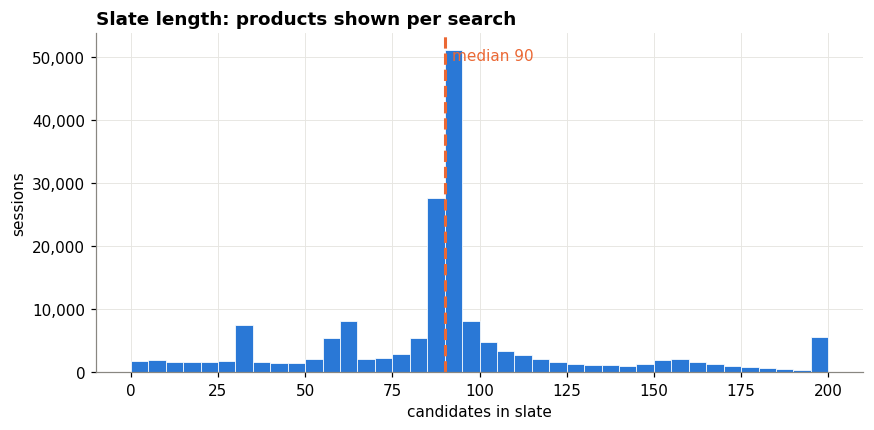

In [9]:
slate_stats = pd.Series(slate_len).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).rename("candidates per session")
display(save_table(slate_stats.to_frame(), "2_2_slate_length"))

fig, ax = plt.subplots()
ax.hist(slate_len, bins=range(0, 205, 5), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(np.median(slate_len), color=ORANGE, linewidth=2, linestyle="--")
ax.text(np.median(slate_len) + 2, ax.get_ylim()[1] * 0.92, f"median {np.median(slate_len):.0f}", color=ORANGE)
ax.set(title="Slate length: products shown per search", xlabel="candidates in slate", ylabel="sessions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
save_fig(fig, "2_2_slate_length")

### 4.2 Interaction funnel

Each candidate carries its strongest interaction, so a purchased item (3) also counts as clicked and carted. The funnel uses cumulative stages: clicked or better (label ≥ 1), carted or better (≥ 2), purchased (3).

In [10]:
stages = [("Impression", label >= 0), ("Click or better", label >= 1),
          ("Cart or better", label >= 2), ("Purchase", label == 3)]
funnel = pd.DataFrame(
    {
        "impressions": [mask.sum() for _, mask in stages],
        "sessions with stage": [np.bincount(cand_sess, weights=mask, minlength=n_sessions).astype(bool).sum()
                                for _, mask in stages],
    },
    index=[name for name, _ in stages],
)
funnel["share of impressions"] = funnel.impressions / funnel.impressions.iloc[0]
funnel["conversion from previous stage"] = funnel.impressions / funnel.impressions.shift(1)
funnel["share of sessions"] = funnel["sessions with stage"] / n_sessions
save_table(funnel, "2_2_funnel")

,impressions,sessions with stage,share of impressions,conversion from previous stage,share of sessions
Impression,15510012,173831,1.0000,NaN,1.0000
Click or better,320896,171728,0.0207,0.0207,0.9879
Cart or better,96409,73438,0.0062,0.3004,0.4225
Purchase,20836,20306,0.0013,0.2161,0.1168


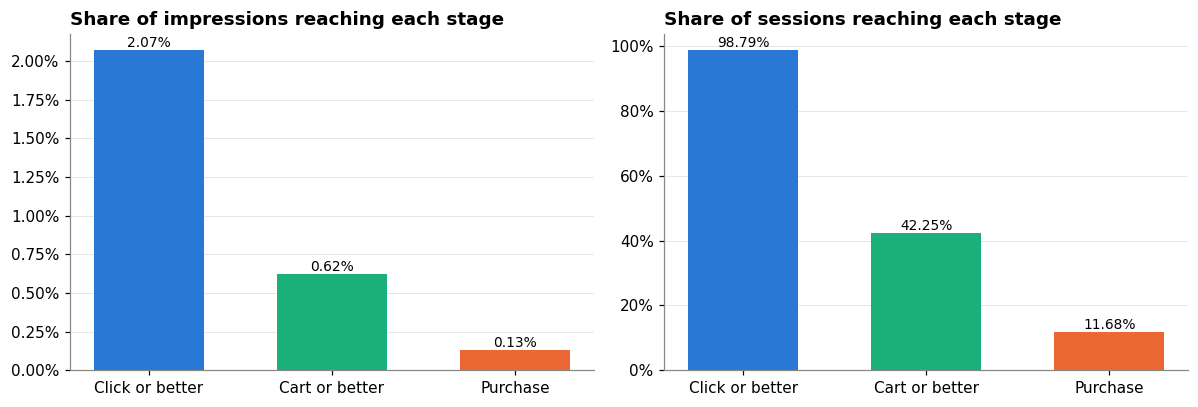

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col, title in [
    (axes[0], "share of impressions", "Share of impressions reaching each stage"),
    (axes[1], "share of sessions", "Share of sessions reaching each stage"),
]:
    values = funnel[col].iloc[1:]
    ax.bar(values.index, values.values, color=[BLUE, AQUA, ORANGE], width=0.6)
    for x, v in zip(values.index, values.values):
        ax.annotate(f"{v:.2%}", (x, v), ha="center", va="bottom", fontsize=9)
    ax.set(title=title)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.grid(axis="x", visible=False)
plt.tight_layout()
save_fig(fig, "2_2_funnel")

**Business reading.**

- Only 2.07% of shown products are engaged and 0.13% are bought, about 47 ignored products for every engaged one.
- At session level, 98.8% of searches engage with at least one product, 42% add something to the cart, and 11.7% end in a purchase.
- Once a product is clicked, 30% go on to the cart, and 22% of carted products are bought.

The right product is usually somewhere in the slate. The business opportunity is **ranking**: moving it from somewhere in about 90 results up to the first screen.

### 4.3 Engagement by display position

The guideline asks for click-through rate by display rank. In JDSearch the candidate order in the file **is not the display order**: every positive is listed before every negative (checked on the full file below). CTR by position would only show how the file was written, so **position bias cannot be studied**. The chart is kept as evidence. As a consequence, we shuffle candidates within each session before any modelling and never use list position as a feature.

Sessions (with a positive) where all positives come first in the file: 100.00%
Sessions with no positive candidate: 2,103 (1.21%)


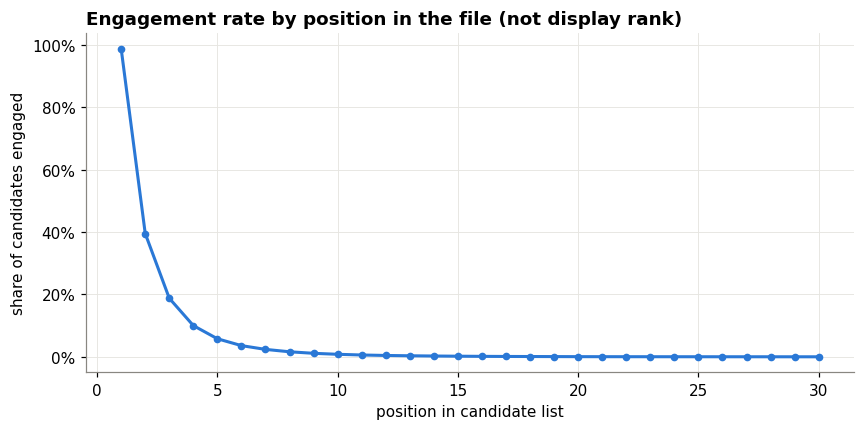

In [12]:
is_pos = label > 0
gap_after_pos = np.zeros(len(label), dtype=bool)
gap_after_pos[1:] = is_pos[1:] & ~is_pos[:-1] & (cand_sess[1:] == cand_sess[:-1])
has_pos = np.bincount(cand_sess, weights=is_pos, minlength=n_sessions) > 0
prefix_share = 1 - len(np.unique(cand_sess[gap_after_pos])) / has_pos.sum()
print(f"Sessions (with a positive) where all positives come first in the file: {prefix_share:.2%}")
print(f"Sessions with no positive candidate: {(~has_pos).sum():,} ({(~has_pos).mean():.2%})")

MAX_POS = 30
rate_by_pos = pd.Series(is_pos[cand_pos < MAX_POS]).groupby(cand_pos[cand_pos < MAX_POS]).mean()
fig, ax = plt.subplots()
ax.plot(rate_by_pos.index + 1, rate_by_pos.values, color=BLUE, linewidth=2, marker="o", markersize=4)
ax.set(title="Engagement rate by position in the file (not display rank)",
       xlabel="position in candidate list", ylabel="share of candidates engaged")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
save_fig(fig, "2_2_position_artifact")

### 4.4 Feedback semantics

| Signal | Where it appears | Meaning |
|---|---|---|
| Positive | Candidate with label 1-3 | Shown and engaged (click, cart, purchase) |
| Explicit negative | Candidate with label 0 | **Shown but ignored.** A real, if noisy, negative signal |
| Unobserved | Any catalogue product not in the session's slate | Never shown, so we cannot tell whether the user would have liked it. Not a negative. |
| Implicit positive | History actions | Past click / cart / follow / purchase. The history contains no negatives. |

Training uses only shown candidates (positives vs explicit negatives). Unobserved products are never treated as negatives.

In [13]:
feedback = pd.DataFrame(
    {
        "count": [is_pos.sum(), (~is_pos).sum(), len(products) - np.isin(cand_items, products.wid.values).sum(),
                  len(hist_wid)],
    },
    index=[
        "Positive impressions (label 1-3)",
        "Explicit negatives (shown, label 0)",
        "Catalogue products never shown in any slate",
        "Implicit positives in history",
    ],
)
feedback.loc["Explicit negatives per positive"] = (~is_pos).sum() / is_pos.sum()
save_table(feedback, "2_2_feedback_semantics")

,count
Positive impressions (label 1-3),"320,896.0000"
"Explicit negatives (shown, label 0)","15,189,116.0000"
Catalogue products never shown in any slate,"3,835,625.0000"
Implicit positives in history,"26,667,260.0000"
Explicit negatives per positive,47.3335


### 4.5 Sparsity: history length, item popularity, cold start

,history actions per user
count,"173,831.0000"
mean,153.4091
std,224.8016
min,1.0000
5%,5.0000
25%,29.0000
50%,78.0000
75%,188.0000
95%,548.0000
99%,"1,055.0000"


,actions,share,share without a query (-1)
CART,11526504,0.4322,0.6894
CLICK,8298894,0.3112,0.7173
ORD,6817283,0.2556,0.4902
FLW,24579,0.0009,0.9959


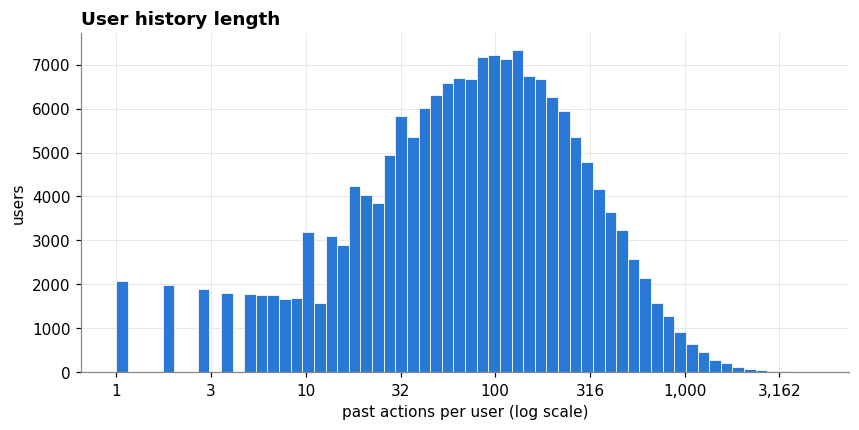

In [14]:
hist_stats = pd.Series(history_len).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).rename("history actions per user")
display(save_table(hist_stats.to_frame(), "2_2_history_length"))

fig, ax = plt.subplots()
ax.hist(np.log10(history_len), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
ax.set(title="User history length", xlabel="past actions per user (log scale)", ylabel="users")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{10 ** v:,.0f}"))
save_fig(fig, "2_2_history_length")

action_mix = pd.DataFrame({"actions": pd.Series(hist_type).value_counts()})
action_mix["share"] = action_mix.actions / action_mix.actions.sum()
action_mix["share without a query (-1)"] = pd.Series(hist_no_query).groupby(hist_type).mean()
save_table(action_mix, "2_2_history_action_mix")

In [15]:
item_exposures = np.unique(cand_wid, return_counts=True)[1]
item_interactions = np.unique(hist_wid, return_counts=True)[1]
cold_candidates = ~np.isin(cand_items, hist_items)

popularity = pd.DataFrame(
    {
        "exposures (candidate slates)": [len(item_exposures), item_exposures.mean(), np.median(item_exposures),
                                         item_exposures.max(), top_share(item_exposures, 0.01),
                                         top_share(item_exposures, 0.20), (item_exposures == 1).mean()],
        "interactions (user histories)": [len(item_interactions), item_interactions.mean(),
                                          np.median(item_interactions), item_interactions.max(),
                                          top_share(item_interactions, 0.01), top_share(item_interactions, 0.20),
                                          (item_interactions == 1).mean()],
    },
    index=["distinct items", "mean per item", "median per item", "max per item",
           "share held by top 1% of items", "share held by top 20% of items", "items seen exactly once"],
)
display(save_table(popularity, "2_2_item_popularity"))
print(f"Cold start: {cold_candidates.mean():.1%} of distinct candidate products never appear in any history")
print(f"Impressions whose product never appears in any history: {(~np.isin(cand_wid, hist_items)).mean():.1%}")

,exposures (candidate slates),interactions (user histories)
distinct items,"8,362,535.0000","5,584,543.0000"
mean per item,1.8547,4.7752
median per item,1.0000,1.0000
max per item,"1,135.0000","44,063.0000"
share held by top 1% of items,0.1435,0.3487
share held by top 20% of items,0.5427,0.7669
items seen exactly once,0.7518,0.5592


Cold start: 80.5% of distinct candidate products never appear in any history


Impressions whose product never appears in any history: 56.5%


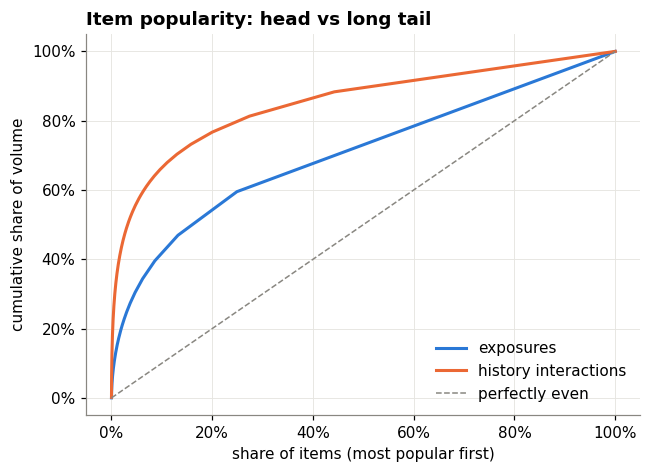

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for counts, color, name in [(item_exposures, BLUE, "exposures"), (item_interactions, ORANGE, "history interactions")]:
    c = np.sort(counts)[::-1]
    ax.plot(np.arange(1, len(c) + 1) / len(c), np.cumsum(c) / c.sum(), color=color, linewidth=2, label=name)
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle="--", label="perfectly even")
ax.set(title="Item popularity: head vs long tail", xlabel="share of items (most popular first)",
       ylabel="cumulative share of volume")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False, loc="lower right")
save_fig(fig, "2_2_item_popularity")

### 4.6 Temporal patterns: time between actions

,between history actions,last action to current query
count,"26,493,429.0000","173,831.0000"
mean,"131,505.2417","466,656.8584"
std,"711,888.8213","1,888,881.1996"
min,0.0000,1.0000
25%,12.0000,69.0000
50%,67.0000,"19,287.0000"
75%,"7,603.0000","184,469.0000"
95%,"589,669.0000","2,233,784.5000"
max,"48,911,483.0000","31,446,033.0000"
share equal to 0,0.1059,0.0000


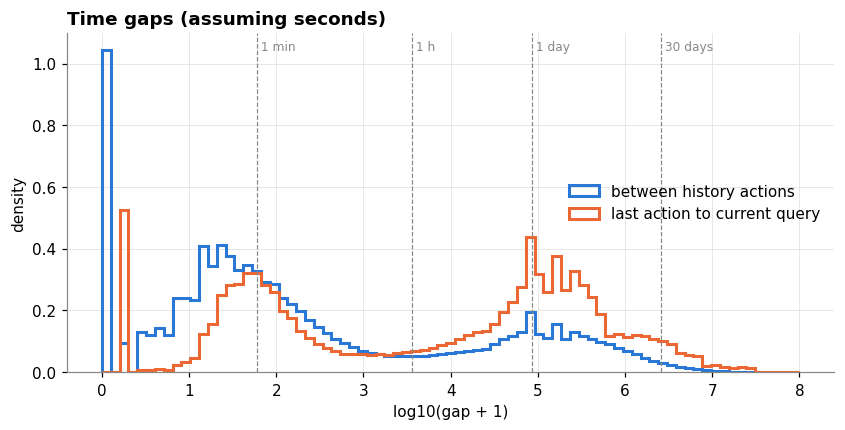

In [17]:
# The first value of each history is always 0 (no previous action), so it is excluded.
first_action = np.zeros(len(history_gaps), dtype=bool)
first_action[hist_offsets[:-1][history_len > 0]] = True
gaps = history_gaps[~first_action]

gap_table = pd.DataFrame(
    {"between history actions": pd.Series(gaps).describe(percentiles=[0.25, 0.5, 0.75, 0.95]),
     "last action to current query": pd.Series(time_since_last).describe(percentiles=[0.25, 0.5, 0.75, 0.95])}
)
gap_table.loc["share equal to 0"] = [(gaps == 0).mean(), (time_since_last == 0).mean()]
display(save_table(gap_table, "2_2_time_gaps"))

fig, ax = plt.subplots()
bins = np.linspace(0, 8, 80)
ax.hist(np.log10(gaps + 1), bins=bins, density=True, histtype="step", linewidth=2, color=BLUE,
        label="between history actions")
ax.hist(np.log10(time_since_last + 1), bins=bins, density=True, histtype="step", linewidth=2, color=ORANGE,
        label="last action to current query")
for seconds, name in [(60, "1 min"), (3600, "1 h"), (86_400, "1 day"), (2_592_000, "30 days")]:
    ax.axvline(np.log10(seconds), color=MUTED, linewidth=0.8, linestyle="--")
    ax.text(np.log10(seconds), ax.get_ylim()[1] * 0.95, f" {name}", color=MUTED, fontsize=8)
ax.set(title="Time gaps (assuming seconds)", xlabel="log10(gap + 1)", ylabel="density")
ax.legend(frameon=False, loc="center right")
save_fig(fig, "2_2_time_gaps")

**Business reading.** Shopping happens in bursts: half of consecutive actions are about a minute apart, followed by long breaks of days or weeks. The current search typically comes hours after the last action, so recent behaviour is likely the most informative. This motivates recency-weighted features.

### 4.7 Engagement by product category

Which categories convert matters commercially. It also shows whether category is informative for the model. Level-1 categories are anonymised IDs.

,impressions,engagement_rate,purchase_rate
cate_id_1,,,
920973,1505607,0.0192,0.0011
63959387,1252530,0.0219,0.0009
98371044,1098576,0.0195,0.0025
98719916,1071768,0.0207,0.0008
68949654,953096,0.0223,0.0008
24093831,814752,0.0233,0.0008
56696958,634617,0.0222,0.0019
31606173,622682,0.0218,0.0010
7098021,588027,0.0185,0.0011


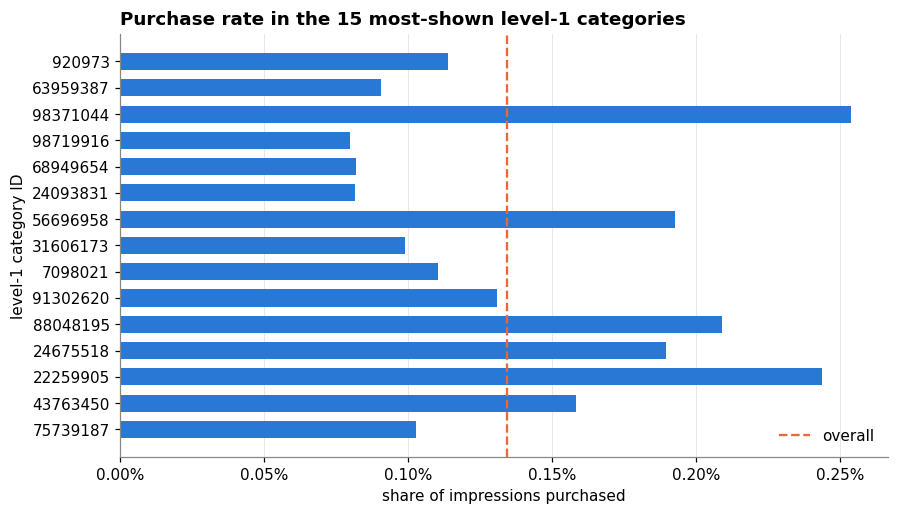

In [18]:
cand_cate1 = np.where(cand_idx >= 0, products.cate_id_1.values[cand_idx], -1)
by_cate = (
    pd.DataFrame({"cate_id_1": cand_cate1, "engaged": label >= 1, "purchased": label == 3})
    .groupby("cate_id_1")
    .agg(impressions=("engaged", "size"), engagement_rate=("engaged", "mean"), purchase_rate=("purchased", "mean"))
    .sort_values("impressions", ascending=False)
)
top_cate = save_table(by_cate.head(15), "2_2_category_engagement")
display(top_cate)

fig, ax = plt.subplots(figsize=(9, 5))
plot = top_cate[::-1]
ax.barh(plot.index.astype(str), plot.purchase_rate, color=BLUE, height=0.65)
ax.axvline((label == 3).mean(), color=ORANGE, linewidth=1.5, linestyle="--", label="overall")
ax.set(title="Purchase rate in the 15 most-shown level-1 categories", xlabel="share of impressions purchased",
       ylabel="level-1 category ID")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=2))
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right")
save_fig(fig, "2_2_category_engagement")

**Business reading.** Engagement rates are similar across categories (about 1.9-2.3%), but purchase rates differ by about 3x (0.08-0.25%). Some categories are browsed much more than they are bought. A ranker that optimises purchases (graded labels) behaves differently from one that optimises clicks, which supports evaluating with graded NDCG.

## 5. Feature dictionary and descriptive statistics (report 2.3)

### 5.1 Raw fields

In [19]:
raw_dictionary = pd.DataFrame(
    [
        ("query", "user", "Current search query, anonymised term IDs", "text (digit string)"),
        ("candidate_wid_list", "user", "Products shown for the query (the slate)", "list of item IDs"),
        ("candidate_label_list", "user", "Interaction per candidate: 0 none, 1 click, 2 cart, 3 purchase", "list of ordinal labels"),
        ("history_qry_list", "user", "Query behind each past action; -1 = not from search", "list of text / -1"),
        ("history_wid_list", "user", "Product of each past action", "list of item IDs"),
        ("history_type_list", "user", "Action type: CLICK, CART, FLW (follow), ORD (purchase)", "list of categorical"),
        ("history_time_list", "user", "Gap to previous action; final value = gap to current query", "list of int (assumed seconds)"),
        ("wid", "product", "Product ID", "categorical ID"),
        ("name", "product", "Product title, anonymised term IDs", "text (digit string)"),
        ("brand_id / brand_name", "product", "Brand", "categorical ID / text"),
        ("cate_id_1..4 / cate_name_1..4", "product", "Four-level category hierarchy", "categorical ID / text"),
        ("shop_id", "product", "Seller shop", "categorical ID"),
    ],
    columns=["field", "file", "description", "type / unit"],
).set_index("field")
save_table(raw_dictionary, "2_3_raw_fields")

,file,description,type / unit
field,,,
query,user,"Current search query, anonymised term IDs",text (digit string)
candidate_wid_list,user,Products shown for the query (the slate),list of item IDs
candidate_label_list,user,"Interaction per candidate: 0 none, 1 click, 2 cart, 3 purchase",list of ordinal labels
history_qry_list,user,Query behind each past action; -1 = not from search,list of text / -1
history_wid_list,user,Product of each past action,list of item IDs
history_type_list,user,"Action type: CLICK, CART, FLW (follow), ORD (purchase)",list of categorical
history_time_list,user,Gap to previous action; final value = gap to current query,list of int (assumed seconds)
wid,product,Product ID,categorical ID
name,product,"Product title, anonymised term IDs",text (digit string)


In [20]:
# Categorical fields: distinct values, examples and missing values.
# shop_id uses -1 for "no shop", so -1 is counted as missing for the ID columns.
def categorical_row(values, missing):
    vc = pd.Series(values).value_counts().drop(-1, errors="ignore")
    return {"distinct values": len(vc), "most common values": ", ".join(map(str, vc.index[:3])),
            "top value share": vc.iloc[0] / vc.sum(), "missing": missing}


categorical = pd.DataFrame(
    {
        "history action type": categorical_row(hist_type, 0),
        "candidate label": categorical_row(label, 0),
        **{col: categorical_row(products[col].values, int((products[col] == -1).sum())) for col in PRODUCT_ID_COLS[1:]},
        "brand_name": {"distinct values": pc.count_distinct(brand_name).as_py(),
                       "most common values": "(anonymised)", "top value share": np.nan,
                       "missing": int(products.brand_missing.sum())},
    }
).T
save_table(categorical, "2_3_categorical_fields")

,distinct values,most common values,top value share,missing
history action type,4,"CART, CLICK, ORD",0.4322,0
candidate label,4,"0, 1, 2",0.9793,0
brand_id,182585,"38645246, 54289642, 33241674",0.0428,0
cate_id_1,76,"68949654, 24093831, 920973",0.0919,0
cate_id_2,671,"92351230, 18907346, 33276684",0.0373,0
cate_id_3,5819,"72526272, 10287851, 64184092",0.0127,0
cate_id_4,7137,"32130995, 462318, 23794926",0.0127,0
shop_id,250934,"21749031, 54486560, 58139116",0.0013,103162
brand_name,171779,(anonymised),NaN,941660


In [21]:
# Text fields: character lengths (term boundaries are not recoverable from the anonymised strings)
name_sample = pd.read_csv(PRODUCT_META_PATH, sep="\t", nrows=200_000, usecols=["name"], dtype=str)["name"]
past_queries = pc.filter(pc.list_flatten(lists["history_qry_list"]), pa.array(~hist_no_query))
text_lengths = pd.DataFrame(
    {
        "query (all sessions)": users["query"].to_pandas().str.len().describe(),
        "past queries (excluding -1)": pd.Series(pc.utf8_length(past_queries).to_numpy()).describe(),
        "product name (first 200k products)": name_sample.str.len().describe(),
        "brand_name (non-empty)": pd.Series(pc.utf8_length(brand_name).to_numpy())[~products.brand_missing.values].describe(),
        "cate_name_3": pd.Series(pc.utf8_length(cate_name_3).to_numpy()).describe(),
    }
).T
save_table(text_lengths, "2_3_text_lengths")

,count,mean,std,min,25%,50%,75%,max
query (all sessions),"173,831.0000",23.4561,16.2440,5.0000,16.0000,17.0000,26.0000,517.0000
past queries (excluding -1),"9,402,778.0000",22.7807,24.3342,0.0000,8.0000,17.0000,26.0000,"12,856.0000"
product name (first 200k products),"200,000.0000",247.3635,71.8319,6.0000,201.0000,242.0000,293.0000,652.0000
brand_name (non-empty),"11,199,587.0000",21.8767,15.5210,4.0000,8.0000,17.0000,35.0000,278.0000
cate_name_3,"12,141,247.0000",16.0298,8.3927,5.0000,8.0000,17.0000,17.0000,134.0000


### 5.2 Engineered features (starter set)

These are the features we plan to use, computed for every (session, candidate) pair on the full data. All history-based features describe the user **before** the current search, so they do not leak the label. Item popularity uses all histories here for description. In the modelling notebooks it will be computed from training sessions only.

In [22]:
KEY = 10**9  # every ID is below 1e9, so session * KEY + id is a unique (session, value) key
action_count = {a: np.bincount(hist_sess, weights=hist_type == a, minlength=n_sessions) for a in ["CLICK", "CART", "ORD"]}

session_features = pd.DataFrame(
    {
        "hist_len": history_len,
        "hist_n_click": action_count["CLICK"],
        "hist_n_cart": action_count["CART"],
        "hist_n_order": action_count["ORD"],
        "hist_share_no_query": np.bincount(hist_sess, weights=hist_no_query, minlength=n_sessions) / np.maximum(history_len, 1),
        "time_since_last_action_h": time_since_last / 3600,
        "history_span_days": history_span_days,
        "query_len_chars": users["query"].to_pandas().str.len().values,
        "slate_len": slate_len,
    }
)

pair = pd.DataFrame({"label": label})
cand_key = cand_sess.astype(np.int64) * KEY + cand_wid
hist_key = hist_sess.astype(np.int64) * KEY + hist_wid
pair["item_seen_before"] = lookup_counts(hist_key, cand_key) > 0
pair["item_ordered_before"] = lookup_counts(hist_key[hist_type == "ORD"], cand_key) > 0

for col, name in [("cate_id_1", "aff_cate1"), ("cate_id_2", "aff_cate2"), ("cate_id_3", "aff_cate3"),
                  ("cate_id_4", "aff_cate4"), ("brand_id", "aff_brand"), ("shop_id", "aff_shop")]:
    values = products[col].values
    cand_val = np.where(cand_idx >= 0, values[cand_idx], -1)
    hist_val = np.where(hist_idx >= 0, values[hist_idx], -1)
    cand_val_key = cand_sess.astype(np.int64) * KEY + cand_val
    known = hist_val >= 0
    pair[name] = np.where(
        cand_val >= 0,
        lookup_counts(hist_sess[known].astype(np.int64) * KEY + hist_val[known], cand_val_key), 0)
    if col == "cate_id_3":
        # Same affinity, but only past purchases count
        ordered = known & (hist_type == "ORD")
        pair["aff_cate3_orders"] = np.where(
            cand_val >= 0,
            lookup_counts(hist_sess[ordered].astype(np.int64) * KEY + hist_val[ordered], cand_val_key), 0)

pair["item_hist_popularity"] = lookup_counts(hist_wid, cand_wid)
pair["item_cold"] = pair.item_hist_popularity == 0
pair["item_in_catalogue"] = cand_idx >= 0
print(f"Pair-level feature table: {pair.shape[0]:,} rows x {pair.shape[1] - 1} features")

Pair-level feature table: 15,510,012 rows x 12 features


**Query-item match** checks whether the candidate's anonymised brand name or level-3 category name appears inside the query string. Matching is done on digit strings, so names shorter than 8 digits are skipped to limit accidental matches. It runs in a Python loop, so it is computed on the model-development sample from section 3.3 (about 4.5M pairs).

In [23]:
s_idx = np.flatnonzero(cand_in_sample)
q_of = users["query"].combine_chunks().take(pa.array(cand_sess[s_idx])).to_pylist()
valid = cand_idx[s_idx] >= 0
take_idx = pa.array(np.where(valid, cand_idx[s_idx], 0))
b_of = brand_name.take(take_idx).to_pylist()
c_of = cate_name_3.take(take_idx).to_pylist()


def match(q, name, ok):
    return ok and len(name) >= 8 and name in q


sample_pair = pair.iloc[s_idx].copy()
sample_pair["query_brand_match"] = [match(q, b, ok) for q, b, ok in zip(q_of, b_of, valid)]
sample_pair["query_cate3_match"] = [match(q, c, ok) for q, c, ok in zip(q_of, c_of, valid)]
print(f"Sample pairs: {len(sample_pair):,}")

Sample pairs: 4,466,970


In [24]:
engineered_dictionary = pd.DataFrame(
    [
        ("hist_len", "session", "Past actions of the user", "count"),
        ("hist_n_click / cart / order", "session", "Past actions by type", "count"),
        ("hist_share_no_query", "session", "Share of past actions not from search", "ratio 0-1"),
        ("time_since_last_action_h", "session", "Gap from last action to current query", "hours (assumed)"),
        ("history_span_days", "session", "Time covered by the user's history", "days (assumed)"),
        ("query_len_chars", "session", "Length of anonymised query string", "characters"),
        ("slate_len", "session", "Candidates shown for the query", "count"),
        ("item_seen_before", "pair", "Candidate appears in user's history", "binary"),
        ("item_ordered_before", "pair", "User purchased the candidate before", "binary"),
        ("aff_cate1..4", "pair", "Past actions in the candidate's category (each level)", "count"),
        ("aff_cate3_orders", "pair", "Past purchases in the candidate's level-3 category", "count"),
        ("aff_brand / aff_shop", "pair", "Past actions with the candidate's brand / shop", "count"),
        ("item_hist_popularity", "item", "Actions on the candidate across all histories", "count"),
        ("item_cold", "item", "Candidate never appears in any history", "binary"),
        ("item_in_catalogue", "item", "Candidate has product metadata", "binary"),
        ("query_brand_match", "pair", "Candidate's brand name occurs in the query", "binary (sample)"),
        ("query_cate3_match", "pair", "Candidate's level-3 category name occurs in the query", "binary (sample)"),
        ("recency-weighted affinity", "pair", "Category / brand affinity with older actions down-weighted (planned)", "float"),
    ],
    columns=["feature", "level", "description", "type / unit"],
).set_index("feature")
save_table(engineered_dictionary, "2_3_engineered_dictionary")

,level,description,type / unit
feature,,,
hist_len,session,Past actions of the user,count
hist_n_click / cart / order,session,Past actions by type,count
hist_share_no_query,session,Share of past actions not from search,ratio 0-1
time_since_last_action_h,session,Gap from last action to current query,hours (assumed)
history_span_days,session,Time covered by the user's history,days (assumed)
query_len_chars,session,Length of anonymised query string,characters
slate_len,session,Candidates shown for the query,count
item_seen_before,pair,Candidate appears in user's history,binary
item_ordered_before,pair,User purchased the candidate before,binary


In [25]:
def numeric_stats(df):
    return pd.DataFrame(
        {"min": df.min(), "max": df.max(), "mean": df.mean(), "median": df.median(),
         "std": df.std(), "missing": df.isna().sum()}
    )


session_stats = numeric_stats(session_features.astype(float))
save_table(session_stats, "2_3_session_feature_stats")

,min,max,mean,median,std,missing
hist_len,1.0000,"4,802.0000",153.4091,78.0000,224.8016,0
hist_n_click,0.0000,"3,575.0000",47.7412,17.0000,93.3323,0
hist_n_cart,0.0000,"3,614.0000",66.3087,29.0000,115.0793,0
hist_n_order,0.0000,"2,962.0000",39.2179,15.0000,70.4069,0
hist_share_no_query,0.0000,1.0000,0.5972,0.6065,0.1996,0
time_since_last_action_h,0.0003,"8,735.0092",129.6269,5.3575,524.6892,0
history_span_days,0.0000,635.2886,231.9745,282.9926,128.1893,0
query_len_chars,5.0000,517.0000,23.4561,17.0000,16.2440,0
slate_len,1.0000,200.0000,89.2247,90.0000,38.8574,0


In [26]:
def with_lift(stats, df, cols):
    stats["mean | engaged"] = df.loc[df.label > 0, cols].astype(float).mean()
    stats["mean | not engaged"] = df.loc[df.label == 0, cols].astype(float).mean()
    stats["lift"] = stats["mean | engaged"] / stats["mean | not engaged"]
    return stats


pair_cols = [c for c in pair.columns if c != "label"]
match_cols = ["query_brand_match", "query_cate3_match"]
pair_stats = pd.concat(
    [
        with_lift(numeric_stats(pair[pair_cols].astype(float)), pair, pair_cols),
        with_lift(numeric_stats(sample_pair[match_cols].astype(float)), sample_pair, match_cols),
    ]
)
save_table(pair_stats, "2_3_pair_feature_stats")

,min,max,mean,median,std,missing,mean | engaged,mean | not engaged,lift
item_seen_before,0.0000,1.0000,0.0078,0.0000,0.0882,0,0.0951,0.0060,15.8372
item_ordered_before,0.0000,1.0000,0.0009,0.0000,0.0292,0,0.0112,0.0006,17.5683
aff_cate1,0.0000,"3,612.0000",25.0035,5.0000,71.4568,0,30.0761,24.8963,1.2081
aff_cate2,0.0000,"2,898.0000",12.6357,1.0000,47.3150,0,16.5701,12.5525,1.3201
aff_cate3,0.0000,"2,783.0000",5.7260,0.0000,25.0402,0,8.2480,5.6727,1.4540
aff_cate3_orders,0.0000,483.0000,0.3513,0.0000,2.5430,0,0.3998,0.3503,1.1411
aff_cate4,0.0000,"2,783.0000",5.2613,0.0000,24.4148,0,7.7510,5.2087,1.4881
aff_brand,0.0000,"2,032.0000",2.3613,0.0000,13.1906,0,3.5045,2.3372,1.4995
aff_shop,0.0000,"1,055.0000",0.4947,0.0000,4.8028,0,1.6107,0.4711,3.4187
item_hist_popularity,0.0000,"44,063.0000",33.3793,0.0000,348.7221,0,233.6359,29.1485,8.0154


`lift` compares the feature's mean for engaged candidates with its mean for ignored ones. A lift well above 1 means the feature separates the classes on its own, an early sign of predictive value before any model is trained.

- **Repeat behaviour is the strongest signal.** Engaged candidates are about 16x more likely to have been seen before and about 18x more likely to have been bought before. It affects few candidates (under 1%), though, so it cannot carry the model alone.
- **Popularity matters.** Engaged items have about 8x more interactions across all users. Cold items are about half as likely to be engaged.
- **Shop affinity (about 3.4x) beats brand and category affinity (about 1.2-1.5x).** Users return to shops they trust.
- **Query-text match is weak (about 1.1x)** with substring matching on anonymised strings. It needs better term-level matching in the final model.

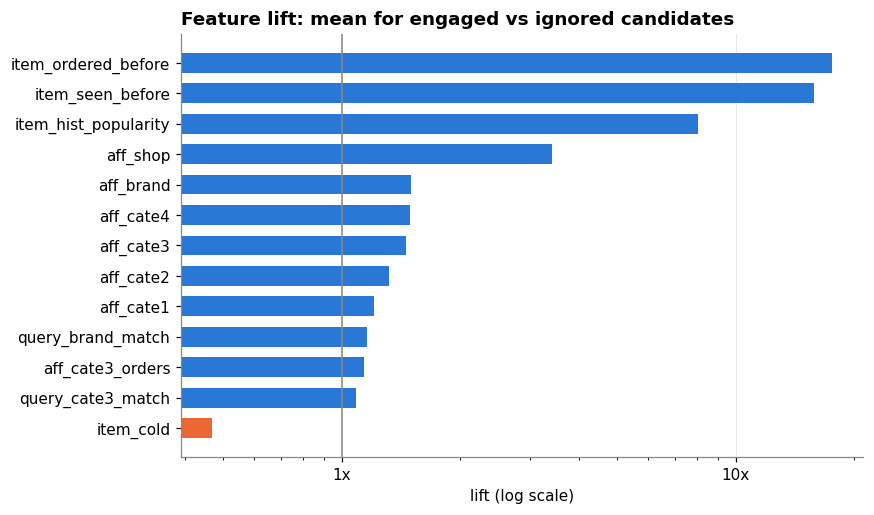

In [27]:
lift = pair_stats["lift"].drop(["item_in_catalogue"]).replace(np.inf, np.nan).dropna().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(lift.index, lift.values, color=[ORANGE if v < 1 else BLUE for v in lift.values], height=0.65)
ax.axvline(1, color=MUTED, linewidth=1)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
ax.set(title="Feature lift: mean for engaged vs ignored candidates", xlabel="lift (log scale)")
ax.grid(axis="y", visible=False)
save_fig(fig, "2_3_feature_lift")

## 6. Limitations and risks

1. **Candidate order is not display order.** Positives are always listed first, so position bias and CTR by rank cannot be studied. We shuffle candidates within each session before modelling.
2. **No user ID and no absolute timestamps.** Each row is treated as a distinct user. The calendar span is unknown and a temporal train/test split is not possible, so we split by session.
3. **Time unit is undocumented.** It is assumed to be seconds, which matches the burst pattern (median gap about one minute).
4. **Anonymised text.** Queries and names are digit strings without term boundaries, so text features are limited to overlaps and lengths.
5. **Slates are pre-filtered to engaged searches.** Almost every session has a positive, so the data cannot answer "will this search convert at all?". The few sessions with no positive are excluded from ranking metrics (the score is undefined for them) but kept as negatives for pointwise training.
6. **Cold start.** Most candidate products never appear in any history, so item-ID features generalise poorly. We rely on brand, category and shop features instead.
7. **Sampling.** Model development uses a 50,000-session random sample. It is representative on headline statistics (section 3.3), but rare segments will have fewer examples. Final numbers will be re-run at the chosen scale.

In [28]:
print("Saved figures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(f"  {path.relative_to(REPORT_DIR)}")
print("Saved tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(f"  {path.relative_to(REPORT_DIR)}")

Saved figures:
  figures/2_2_category_engagement.png
  figures/2_2_funnel.png
  figures/2_2_history_length.png
  figures/2_2_item_popularity.png
  figures/2_2_position_artifact.png
  figures/2_2_slate_length.png
  figures/2_2_time_gaps.png
  figures/2_3_feature_lift.png
Saved tables:
  tables/2_1_entity_counts.csv
  tables/2_1_history_span_days.csv
  tables/2_1_sample_vs_full.csv
  tables/2_2_category_engagement.csv
  tables/2_2_feedback_semantics.csv
  tables/2_2_funnel.csv
  tables/2_2_history_action_mix.csv
  tables/2_2_history_length.csv
  tables/2_2_item_popularity.csv
  tables/2_2_slate_length.csv
  tables/2_2_time_gaps.csv
  tables/2_3_categorical_fields.csv
  tables/2_3_engineered_dictionary.csv
  tables/2_3_pair_feature_stats.csv
  tables/2_3_raw_fields.csv
  tables/2_3_session_feature_stats.csv
  tables/2_3_text_lengths.csv
